# 03 — QR Algorithms from the Report

This notebook implements the two QR paths described in the report:

- compact dense QR with Householder reflectors;
- structured Householder row insertion for the project matrix.

Both methods apply $Q$ or $Q^T$ implicitly. The optimized row-insertion solver applies each reflector immediately to the right-hand side instead of storing it. NumPy's dense solver is used only as an accuracy reference.

In [9]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'DejaVu Sans'

from lib.qr_householder import (
    apply_Q,
    householder_vector,
    qr_solve_row_insertion,
    dense_qr_solve
)
from lib.utils import (
    build_augmented_system,
    compute_gradient,
    compute_loss,
    load_ml_cup,
    relative_error,
    solve_exact,
)

## Problem Setup

We solve

$$
\min_w \left\|Aw-b\right\|_2,\qquad
A=\begin{bmatrix}X^T\\ \lambda I_m\end{bmatrix},\qquad
b=\begin{bmatrix}y\\0\end{bmatrix}.
$$

The structured method uses the equivalent row-permuted system

$$
\widetilde A=\begin{bmatrix}\lambda I_m\\X^T\end{bmatrix},\qquad
\widetilde b=\begin{bmatrix}0\\y\end{bmatrix}.
$$

In [10]:
# Load the deterministic project instance.
data_path = Path('Dataset') / 'ML-CUP25-TR.csv'
X, y, m, n = load_ml_cup(data_path, seed=42)
lam = 0.5
m_dense = min(60, m)

print(f'Dataset: X={X.shape}, y={y.shape}')
print(f'Regularization: λ={lam}')
print(f'Dense demonstration size: m={m_dense}, n={n}')

Dataset: X=(500, 12), y=(12,)
Regularization: λ=0.5
Dense demonstration size: m=60, n=12


## Test on One Householder Reflector

For a normalized vector $u$, the library represents a reflector as $H=I-2uu^T$. The following check confirms that $Hz$ has only its first component different from zero.

In [11]:
z = np.array([3.0, -4.0, 2.0, 1.0])
u, alpha = householder_vector(z)
H = np.eye(z.size) - 2.0 * np.outer(u, u) # = I - 2uu^T
target = np.r_[alpha, np.zeros(z.size - 1)] # = [α, 0, 0, 0]^T

action_error = np.linalg.norm(H @ z - target) / np.linalg.norm(z)
orthogonality_error = np.linalg.norm(H.T @ H - np.eye(z.size))

print(f'Elimination error:  {action_error:.3e}')
print(f'Orthogonality error:{orthogonality_error: .3e}')

Elimination error:  9.247e-17
Orthogonality error: 3.010e-16


## Test on a Compact Dense Householder QR

This is the canonical algorithm in the report. It factorizes the complete augmented matrix, computes $Q^Tb$ from the stored reflectors, and solves $Rw=c$. We use a small subset because generic dense QR costs $O((m+n)m^2)$.

In [12]:
X_dense = X[:m_dense, :] # pick the first "m_dense" rows of the ML-CUP dataset
A_dense, b_dense = build_augmented_system(X_dense, y, lam) # Aw = b

# Count the time for the dense QR solver
start = time.perf_counter()
w_dense, R_dense, dense_reflectors = dense_qr_solve(X_dense, y, lam)
dense_time = time.perf_counter() - start

w_dense_reference, _, _ = solve_exact(X_dense, y, lam)

reduced = np.zeros_like(A_dense)
reduced[:m_dense, :] = R_dense
reconstructed = np.column_stack([
    apply_Q(dense_reflectors, reduced[:, j], A_dense.shape[0])
    for j in range(m_dense)
])

probe_dense = np.linspace(-1.0, 1.0, A_dense.shape[0])
round_trip = apply_Q(
    dense_reflectors,
    apply_Q(dense_reflectors, probe_dense, A_dense.shape[0], transpose=True),
    A_dense.shape[0],
)

dense_metrics = {
    'QR reconstruction': np.linalg.norm(reconstructed - A_dense) / np.linalg.norm(A_dense),
    'Q/QT round trip': np.linalg.norm(round_trip - probe_dense) / np.linalg.norm(probe_dense),
    'Solution error': relative_error(w_dense, w_dense_reference),
}

for name, value in dense_metrics.items():
    print(f'{name:<22} {value:.3e}')
print(f'{"Elapsed time (ms)":<22} {dense_time * 1e3:.3f}')

QR reconstruction      5.462e-16
Q/QT round trip        4.426e-16
Solution error         7.347e-14
Elapsed time (ms)      7.127


The reconstruction and round-trip errors test both reflector orders: increasing order applies $Q^T$, while decreasing order applies $Q$.

## Structured Householder Row Insertion

The report starts from $R_0=\lambda I_m$ and inserts the $n$ rows of $X^T$. For every inserted row, a sequence of two-dimensional reflectors eliminates its entries from left to right. The solver immediately applies each reflector to the right-hand side, avoiding storage and a second scan while preserving the same row-insertion order. The total cost is $O(nm^2+m^2)$, which is quadratic in $m$ when $n$ is fixed.

In [13]:
# Algorithm execution: Row Insertion solver
w_row, row_time = qr_solve_row_insertion(X, y, lam)

# Algorithm execution: Exact solver
w_exact, f_exact, _ = solve_exact(X, y, lam)

In [14]:
print(f'{"Metric":<30} {"Value":>16}')
print('-' * 48)

w_error = relative_error(w_row, w_exact)
print(f'{"Solution error":<30} {w_error:>16.3e}')

objective_scale = max(abs(f_exact), np.finfo(float).eps)
f_row = compute_loss(w_row, X, y, lam)
print(f'{"Relative objective gap":<30} {abs(f_row - f_exact) / objective_scale:>16.3e}')

gradient_scale = max(np.linalg.norm(X @ y), 1.0)
stationarity = np.linalg.norm(compute_gradient(w_row, X, y, lam)) / gradient_scale
print(f'{"Scaled stationarity":<30} {stationarity:>16.3e}')

print(f'{"Row insertion elapsed time (ms)":<30} {row_time * 1e3:>16.3f}')

Metric                                    Value
------------------------------------------------
Solution error                        6.037e-13
Relative objective gap                1.498e-16
Scaled stationarity                   9.518e-17
Row insertion elapsed time (ms)           34.269


## Runtime Scaling

We finally time both report algorithms on nested subsets with fixed $n$. The reference slopes show the expected cubic cost of generic dense QR and quadratic cost of structured row insertion.

In [15]:
def median_time(function, *args, repeats=3):
    """Return a median wall time after one warm-up call."""
    function(*args)
    samples = []
    for _ in range(repeats):
        start = time.perf_counter()
        function(*args)
        samples.append(time.perf_counter() - start)
    return float(np.median(samples))

m_scaling_sizes = np.array([50, 100, 200, 350, 500])
dense_times = []
row_times = []

for m_size in m_scaling_sizes:
    X_value = X[:m_size, :]
    dense_times.append(median_time(dense_qr_solve, X_value, y, lam))
    row_times.append(median_time(qr_solve_row_insertion, X_value, y, lam))

dense_times = np.array(dense_times)
row_times = np.array(row_times)

print(f'{"m":>5} {"Dense QR (ms)":>16} {"Row insertion (ms)":>20}')
print('-' * 45)
for m_size, dense_value, row_value in zip(m_scaling_sizes, dense_times, row_times):
    print(f'{m_size:>5d} {dense_value * 1e3:>16.3f} {row_value * 1e3:>20.3f}')

    m    Dense QR (ms)   Row insertion (ms)
---------------------------------------------
   50            2.915                6.634
  100            4.782                6.936
  200           15.883               12.612
  350           34.694               22.234
  500           92.275               31.718


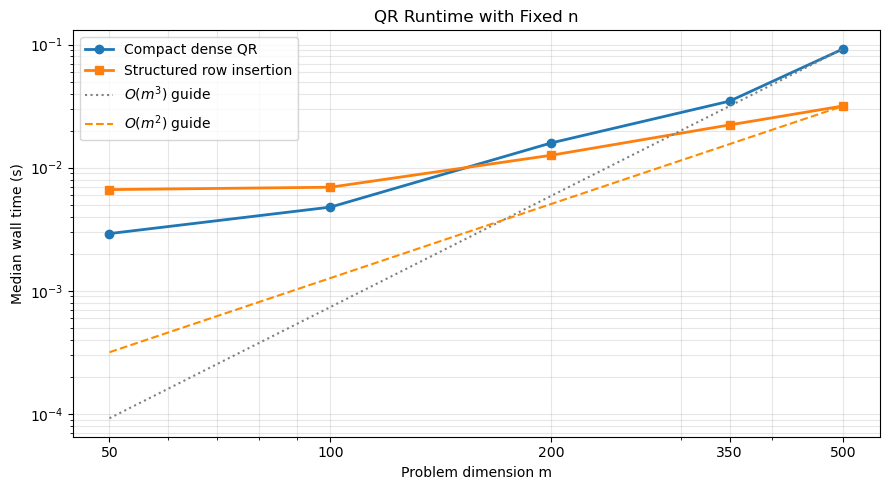

In [16]:
quadratic_guide = row_times[-1] * (m_scaling_sizes / m_scaling_sizes[-1]) ** 2
cubic_guide = dense_times[-1] * (m_scaling_sizes / m_scaling_sizes[-1]) ** 3

plt.figure(figsize=(9, 5))
plt.loglog(m_scaling_sizes, dense_times, 'o-', lw=2, label='Compact dense QR')
plt.loglog(m_scaling_sizes, row_times, 's-', lw=2, label='Structured row insertion')
plt.loglog(m_scaling_sizes, cubic_guide, ':', color='gray', label='$O(m^3)$ guide')
plt.loglog(m_scaling_sizes, quadratic_guide, '--', color='darkorange', label='$O(m^2)$ guide')
plt.xlabel('Problem dimension m')
# Display every sampled problem size on the logarithmic x-axis.
plt.xticks(m_scaling_sizes, [str(m_size) for m_size in m_scaling_sizes])
plt.ylabel('Median wall time (s)')
plt.title('QR Runtime with Fixed n')
plt.grid(alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
plt.show()

Results:

- The reference slopes describe the asymptotic operation counts derived in the report.
- At moderate sizes, vectorized dense operations may still be faster than the Python-level row-insertion loops.
- The structured method becomes preferable asymptotically because it removes the cubic term.

## Summary

- The dense algorithm reproduces the compact Householder QR derivation from the report.
- Forward and reverse reflector scans correctly apply $Q^T$ and $Q$.
- Structured row insertion gives the same regularized least-squares solution while exploiting $\lambda I_m$.
- With fixed $n$, row insertion removes the cubic term of generic dense QR.